In [ ]:
# Libs
import cmcrameri
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import xarray as xr
import numpy as np
from scipy.ndimage import label, sum as ndi_sum
from skimage.measure import regionprops
import croco_plot as cplot
%matplotlib inline


In [23]:
# Params

min_vort = 1.5e-5
min_area = 50
min_circularity = 0.2

figsize = (8,6)

vort_cmap=cmcrameri.cm.vik
gridline_style = {'draw_labels': True, 'linestyle': '--', 'linewidth': 0.3}

data_path = '/home/guilremy/IGE-Stochastic/Data/swio_avg_suf.nc'
grid_path = '/home/guilremy/IGE-Stochastic/Data/croco_grid_swio2.nc'

lon, lat, pm, pn, msk, msk_inv, angle, _ = cplot.utils.load_grid(grid_path)
velocity, vorticity = cplot.utils.load_data(data_path, ('V_hor','vort'))

velocity, vorticity = velocity[:,0,:,:], vorticity[:,0,:,:]


Grid loaded.
Data in /home/guilremy/IGE-Stochastic/Data/swio_avg_suf.nc loaded.


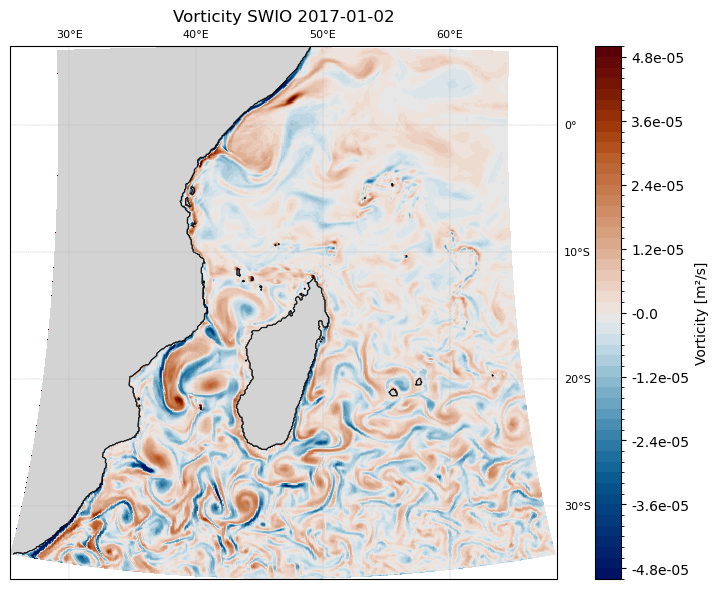

In [24]:
# Plot
date = np.datetime_as_string(vorticity.time.data[0], 'D')

fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_title(f"Vorticity SWIO {date}")

levels = np.linspace(-0.00005, 0.00005, 51)
norm = mpl.colors.BoundaryNorm(levels, vort_cmap.N)

pcm = ax.pcolormesh(lon[:, :], lat[:, :],  vorticity[0], cmap=vort_cmap, norm=norm, transform=ccrs.PlateCarree())

ax.contourf(lon, lat, msk_inv, colors='lightgray')
ax.contour(lon, lat, msk, colors='k', linewidths=0.2)

gl = ax.gridlines(crs=ccrs.PlateCarree(), **gridline_style)
gl.bottom_labels = False
gl.left_labels = False
gl.xlabel_style = gl.ylabel_style = {'size': 8, 'color': 'k'}

cb = plt.colorbar(pcm, ax=ax, label=r'Vorticity [m²/s]', orientation='vertical')
cb.set_ticks(cb.get_ticks())
cb.ax.set_yticklabels(np.round(cb.get_ticks(), 6))

plt.tight_layout()
plt.show()


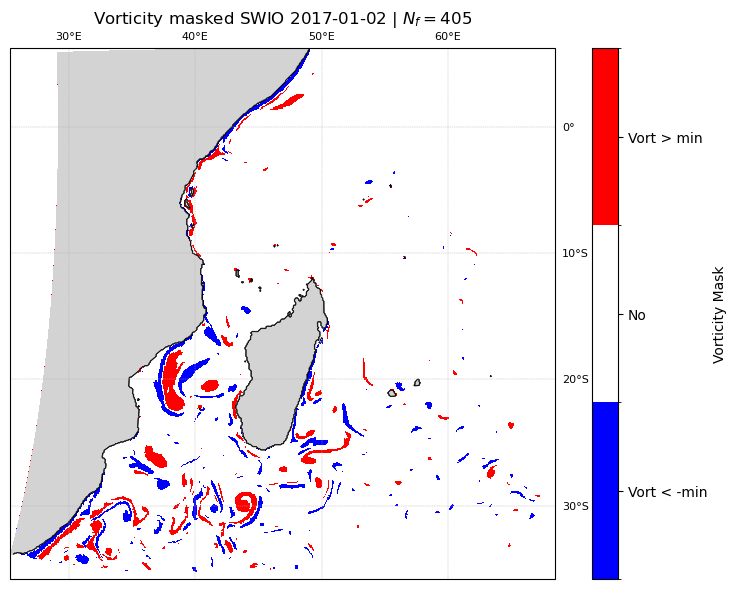

In [25]:
# MASKING

# Custom colormap: blue (negative), white (neutral), red (positive)
mask_cmap = mcolors.ListedColormap(["blue", "white", "red"])

# Normalization to align -1, 0, 1 to colormap indices
mask_norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], mask_cmap.N)

# Ternary mask: 0 = no mask, 1 = positive mask, -1 = negative mask
mask_values = np.zeros_like(vorticity[0].data, dtype=int)
mask_values[vorticity[0].data > min_vort] = 1   # Positive vorticity
mask_values[vorticity[0].data < -min_vort] = -1 # Negative vorticity


labeled_mask, num_features = label(mask_values)

fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_title(rf"Vorticity masked SWIO {date} | $N_f={num_features}$")

# Plot the mask
pcmmask = ax.pcolormesh(lon[:, :], lat[:, :], mask_values, cmap=mask_cmap, norm=mask_norm, transform=ccrs.PlateCarree())

# Other map layers
ax.contourf(lon, lat, msk_inv, colors='lightgray')
ax.contour(lon, lat, msk, colors='k', linewidths=0.2)

# Gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), **gridline_style)
gl.bottom_labels = False
gl.left_labels = False
gl.xlabel_style = gl.ylabel_style = {'size': 8, 'color': 'k'}

# Colorbar
cb = plt.colorbar(pcmmask, ax=ax, ticks=[-1, 0, 1], orientation='vertical')
cb.ax.set_yticklabels(['Vort < -min', 'No', 'Vort > min'])
cb.set_label('Vorticity Mask')

plt.tight_layout()
plt.show()



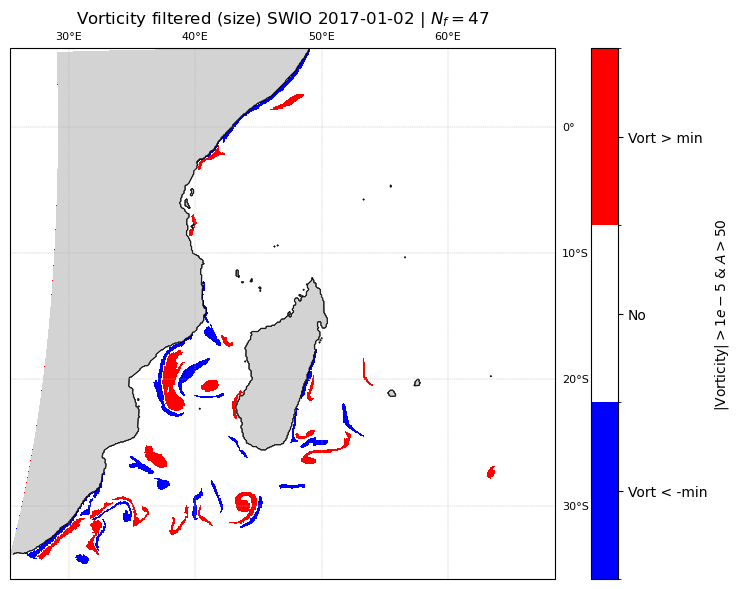

In [ ]:
# Initialize filtered mask as 0
filtered_mask = np.zeros_like(mask_values, dtype=int)

# --- Process positive vorticity regions ---
pos_mask = (mask_values == 1)
labeled_pos, num_pos = label(pos_mask)
region_areas_pos = ndi_sum(pos_mask, labeled_pos, index=range(1, num_pos + 1))

for i, area in enumerate(region_areas_pos):
    if area >= min_area:
        filtered_mask[labeled_pos == (i + 1)] = 1  # Keep as positive mask

# --- Process negative vorticity regions ---
neg_mask = (mask_values == -1)
labeled_neg, num_neg = label(neg_mask)
region_areas_neg = ndi_sum(neg_mask, labeled_neg, index=range(1, num_neg + 1))

for i, area in enumerate(region_areas_neg):
    if area >= min_area:
        filtered_mask[labeled_neg == (i + 1)] = -1  # Keep as negative mask

# Count total filtered features (optional)
num_size_filtered = (np.max(labeled_pos) + np.max(labeled_neg))  # crude total count of objects before area filtering
num_filtered_kept = len(region_areas_pos[region_areas_pos >= min_area]) + len(region_areas_neg[region_areas_neg >= min_area])

fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_title(rf"Vorticity filtered (size) SWIO {date} | $N_f={num_filtered_kept}$")

# Use same colormap and norm as before (centered on 0)
pcmfilt = ax.pcolormesh(
    lon[:, :], lat[:, :], filtered_mask,
    cmap=mask_cmap, norm=mask_norm,
    transform=ccrs.PlateCarree()
)

# Other map layers
ax.contourf(lon, lat, msk_inv, colors='lightgray')
ax.contour(lon, lat, msk, colors='k', linewidths=0.2)

# Gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), **gridline_style)
gl.bottom_labels = False
gl.left_labels = False
gl.xlabel_style = gl.ylabel_style = {'size': 8, 'color': 'k'}

# Colorbar properly labeled
cb = plt.colorbar(pcmfilt, ax=ax, ticks=[-1, 0, 1], orientation='vertical')
cb.ax.set_yticklabels(['Negative vorticity', 'No', 'Positive vorticity'])
cb.set_label(rf'$|$Vorticity$| > 1e-5$ & $A > {min_area}$')

plt.tight_layout()
plt.show()



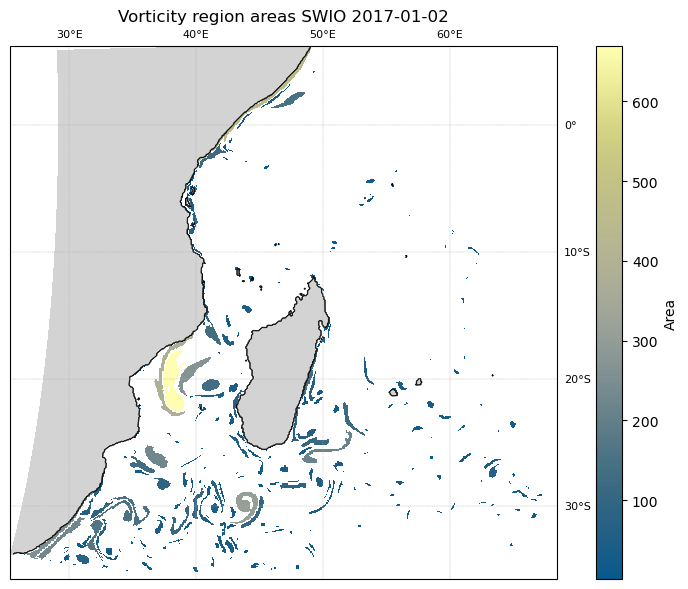

In [27]:
# SIZE PLOTTING

# Separate masks
pos_mask = (mask_values == 1)
neg_mask = (mask_values == -1)

# Label connected components
labeled_pos, _ = label(pos_mask)
labeled_neg, _ = label(neg_mask)

# Initialize float mask for area, and integer mask for sign
filtered_area_mask = np.zeros_like(mask_values, dtype=float)
sign_mask = np.zeros_like(mask_values, dtype=int)

# Process positive regions
props_pos = regionprops(labeled_pos)
for prop in props_pos:
    area = prop.area
    filtered_area_mask[labeled_pos == prop.label] = area
    sign_mask[labeled_pos == prop.label] = 1  # mark as positive

# Process negative regions
props_neg = regionprops(labeled_neg)
for prop in props_neg:
    area = prop.area
    filtered_area_mask[labeled_neg == prop.label] = area
    sign_mask[labeled_neg == prop.label] = -1  # mark as negative

# If you want to remove the largest feature (optional)
max_area = np.nanmax(filtered_area_mask)
filtered_area_mask[filtered_area_mask == max_area] = 0
max_area = np.nanmax(filtered_area_mask)
filtered_area_mask[filtered_area_mask == max_area] = 0
max_area = np.nanmax(filtered_area_mask)
filtered_area_mask[filtered_area_mask == max_area] = 0

sign_mask[filtered_area_mask == max_area] = 0

fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_title(rf"Vorticity region areas SWIO {date}")

# Mask for plotting (zero becomes transparent)
filtered_area_mask_masked = np.ma.masked_where(filtered_area_mask == 0, filtered_area_mask)

# Plot area
pcmfilt2 = ax.pcolormesh(
    lon[:, :], lat[:, :], filtered_area_mask_masked,
    cmap=cmcrameri.cm.nuuk, transform=ccrs.PlateCarree()
)

# Optional: gray background for no regions
ax.pcolormesh(
    lon, lat, np.where(filtered_area_mask == 0, 1, np.nan),
    cmap="gray", vmin=0, vmax=1, transform=ccrs.PlateCarree()
)

# Other map layers
ax.contourf(lon, lat, msk_inv, colors='lightgray')
ax.contour(lon, lat, msk, colors='k', linewidths=0.2)

# Gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), **gridline_style)
gl.bottom_labels = False
gl.left_labels = False
gl.xlabel_style = gl.ylabel_style = {'size': 8, 'color': 'k'}

# Colorbar
cb = plt.colorbar(pcmfilt2, ax=ax, label='Area', orientation='vertical')

plt.tight_layout()
plt.show()



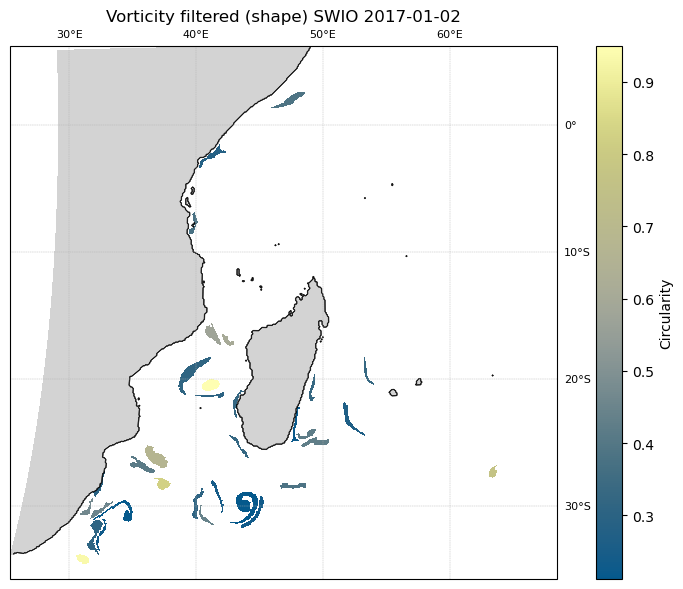

In [28]:
# SHAPE FILTERING

# Separate masks
pos_mask = (mask_values == 1)
neg_mask = (mask_values == -1)

# Label connected components
labeled_pos, _ = label(pos_mask)
labeled_neg, _ = label(neg_mask)

# Initialize output masks
filtered_circularity_mask = np.zeros_like(mask_values, dtype=float)  # store circularity
filtered_area_mask = np.zeros_like(mask_values, dtype=float)         # store area
sign_mask = np.zeros_like(mask_values, dtype=int)                    # store sign info

# --- Process positive vorticity regions ---
props_pos = regionprops(labeled_pos)
for prop in props_pos:
    area = prop.area
    perimeter = prop.perimeter
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    if area >= min_area and circularity >= min_circularity:
        filtered_area_mask[labeled_pos == prop.label] = area
        filtered_circularity_mask[labeled_pos == prop.label] = circularity
        sign_mask[labeled_pos == prop.label] = 1  # positive

# --- Process negative vorticity regions ---
props_neg = regionprops(labeled_neg)
for prop in props_neg:
    area = prop.area
    perimeter = prop.perimeter
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    if area >= min_area and circularity >= min_circularity:
        filtered_area_mask[labeled_neg == prop.label] = area
        filtered_circularity_mask[labeled_neg == prop.label] = circularity
        sign_mask[labeled_neg == prop.label] = -1  # negative

# If you want to remove the largest feature (optional)
max_area = np.nanmax(filtered_area_mask)
filtered_circularity_mask[filtered_area_mask == max_area] = 0
filtered_area_mask[filtered_area_mask == max_area] = 0
max_area = np.nanmax(filtered_area_mask)
filtered_circularity_mask[filtered_area_mask == max_area] = 0
filtered_area_mask[filtered_area_mask == max_area] = 0
max_area = np.nanmax(filtered_area_mask)
filtered_circularity_mask[filtered_area_mask == max_area] = 0
filtered_area_mask[filtered_area_mask == max_area] = 0

fig, ax = plt.subplots(1, 1, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_title(rf"Vorticity filtered (shape) SWIO {date}")

# Mask for pcolormesh (hide zeros)
filtered_circularity_masked = np.ma.masked_where(filtered_circularity_mask == 0, filtered_circularity_mask)

# Plot circularity (color intensity shows roundness)
pcmfilt2 = ax.pcolormesh(
    lon[:, :], lat[:, :], filtered_circularity_masked,
    cmap=cmcrameri.cm.nuuk, transform=ccrs.PlateCarree()
)

# Optional: gray background for empty areas
ax.pcolormesh(
    lon, lat, np.where(filtered_circularity_mask == 0, 1, np.nan),
    cmap="gray", vmin=0, vmax=1, transform=ccrs.PlateCarree()
)

# Other map layers (landmask, domain)
ax.contourf(lon, lat, msk_inv, colors='lightgray')
ax.contour(lon, lat, msk, colors='k', linewidths=0.2)

# Gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), **gridline_style)
gl.bottom_labels = False
gl.left_labels = False
gl.xlabel_style = gl.ylabel_style = {'size': 8, 'color': 'k'}

# Colorbar for circularity
cb = plt.colorbar(pcmfilt2, ax=ax, label='Circularity', orientation='vertical')

plt.tight_layout()
plt.show()

